In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc, approx_count_distinct


# 2. Iniciar Sesión de Spark
spark = SparkSession.builder \
    .appName("ExploracionDatos") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

# 3. Cargar el CSV
# inferSchema=True hace que Spark lea el archivo dos veces para adivinar los tipos de datos
# Si el archivo es EXTREMADAMENTE pesado, podrías quitarlo y todo se leerá como String
print("Cargando archivo... esto puede tardar dependiendo del tamaño.")
df = spark.read.csv("2019-Oct.csv", header=True, inferSchema=True)

# --- EXPLORACIÓN INICIAL ---

# A. Ver el esquema (¿Qué columnas hay y de qué tipo?)
print("Esquema de los datos:")
df.printSchema()

# B. Contar total de registros
# Nota: En Spark esto dispara el procesamiento real
total_filas = df.count()
print(f"Total de registros: {total_filas:,}")

# C. Ver las primeras 5 filas de forma estética
print("Vista previa de datos:")
df.show(5)

# D. Estadísticas descriptivas de columnas numéricas (precio, por ejemplo)
print("Resumen estadístico del precio:")
df.select("price").describe().show()

# E. Análisis de valores nulos por columna
print("Conteo de valores nulos:")
for columna in df.columns:
    nulos = df.filter(col(columna).isNull()).count()
    if nulos > 0:
        print(f"Columna {columna}: {nulos} nulos")

# F. Ejemplo de Agregación: Top 10 categorías más frecuentes
print("Top 10 categorías con más eventos:")
df.groupBy("category_code") \
    .count() \
    .sort(desc("count")) \
    .show(10)

# G. Ejemplo de conteo de valores únicos (Aproximado para ganar velocidad)
print("Conteo aproximado de productos únicos:")
df.select(approx_count_distinct("product_id")).show()

# Detener sesión al terminar
# spark.stop()


Cargando archivo... esto puede tardar dependiendo del tamaño.
Esquema de los datos:
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)

Total de registros: 42,448,764
Vista previa de datos:
+-------------------+----------+----------+-------------------+--------------------+--------+-------+---------+--------------------+
|         event_time|event_type|product_id|        category_id|       category_code|   brand|  price|  user_id|        user_session|
+-------------------+----------+----------+-------------------+--------------------+--------+-------+---------+--------------------+
|2019-09-30 17:00:00|      view|  44600062|2103807459595387724|                NULL

In [7]:
# === Limpieza de datos antes de EDA ===
print("=== Limpieza de valores vacíos y nulos ===")

# Reemplazar cadenas vacías por NULL solo en columnas string
string_cols = [c for c, t in df.dtypes if t == 'string']
df_clean = df.na.replace("", None, subset=string_cols) if string_cols else df

# Opcional: eliminar filas que tengan cualquier valor nulo
# Si quieres mantener filas con algunos valores faltantes, no uses dropna().
print(f"Filas antes de dropna: {df_clean.count()}")
df_clean = df_clean.dropna()
print(f"Filas después de dropna: {df_clean.count()}")

# Reutiliza df_clean en análisis posteriores si se desea
# df = df_clean


=== Limpieza de valores vacíos y nulos ===
Filas antes de dropna: 42448764
Filas después de dropna: 26560620


In [8]:
df=df_clean

In [9]:
# === Exploración de datos estilo pandas con PySpark ===
from pyspark.sql.functions import col, when, count, desc

print("=== EDA estilo pandas con PySpark ===")

# Shape y columnas
num_rows = df.count()
num_cols = len(df.columns)
print(f"shape: ({num_rows}, {num_cols})")
print("columnas:", df.columns)

# Tipos de datos
print("\ndtypes:")
for nombre, tipo in df.dtypes:
    print(f"  {nombre}: {tipo}")

# Head
print("\nhead() equivalente:")
print(df.limit(5).toPandas())

# Describe de columnas numéricas
print("\ndescribe() equivalente:")
print(df.describe().toPandas())

# Conteo de valores nulos/empty por columna
print("\nValores nulos / vacíos por columna:")
null_exprs = []
for c, dtype in df.dtypes:
    if dtype == "string":
        null_exprs.append(count(when(col(c).isNull() | (col(c) == ""), c)).alias(c))
    else:
        null_exprs.append(count(when(col(c).isNull(), c)).alias(c))

null_counts = df.select(null_exprs)
print(null_counts.toPandas().transpose())

# Recomendar eliminar filas incompletas si se desea un análisis limpio
print("\nRecomendación: usar df.dropna() o df.na.drop() para eliminar filas con valores faltantes antes de ciertos análisis.")

# Conteo de valores únicos para algunas columnas clave
candidatas = [c for c in ["category_code", "product_id", "user_id"] if c in df.columns]
for c in candidatas:
    total_unicos = df.select(c).distinct().count()
    print(f"{c}: {total_unicos} valores únicos")

# Top N de una columna categórica típica
if "category_code" in df.columns:
    print("\nTop 10 category_code:")
    print(df.groupBy("category_code").count().orderBy(desc("count")).limit(10).toPandas())

# Muestra una muestra aleatoria pequeña como si fuera sample()
print("\nSample aleatorio (10 filas):")
print(df.sample(withReplacement=False, fraction=0.001, seed=42).limit(10).toPandas())


=== EDA estilo pandas con PySpark ===
shape: (26560620, 9)
columnas: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

dtypes:
  event_time: timestamp
  event_type: string
  product_id: int
  category_id: bigint
  category_code: string
  brand: string
  price: double
  user_id: int
  user_session: string

head() equivalente:
           event_time event_type  product_id          category_id  \
0 2019-09-30 17:00:00       view     3900821  2053013552326770905   
1 2019-09-30 17:00:01       view     1307067  2053013558920217191   
2 2019-09-30 17:00:04       view     1004237  2053013555631882655   
3 2019-09-30 17:00:05       view     1480613  2053013561092866779   
4 2019-09-30 17:00:10       view    28719074  2053013565480109009   

                         category_code   brand    price    user_id  \
0  appliances.environment.water_heater    aqua    33.20  554748717   
1                   computers.notebook  lenovo 

=== Histograma de precios por brand ===


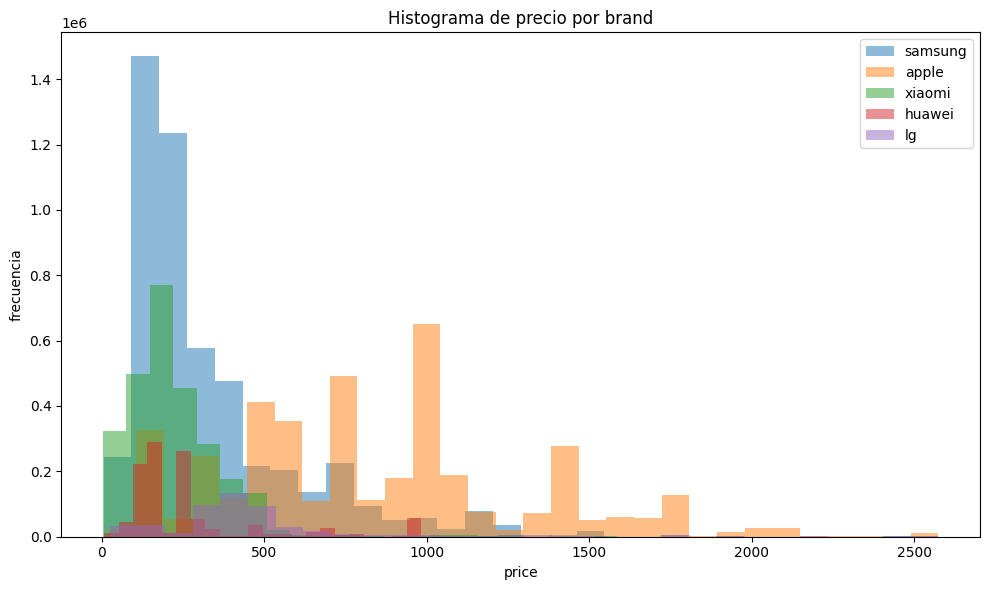

In [10]:
# === Histograma de precios por brand ===
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, expr

print("=== Histograma de precios por brand ===")

if "brand" in df.columns and "price" in df.columns:
    # Asegura que price se convierta a numérico sin fallar en valores mal formados
    if dict(df.dtypes)["price"] == "string":
        df_plot = df.withColumn("price_num", expr("try_cast(price as double)"))
    else:
        df_plot = df.withColumn("price_num", col("price").cast("double"))

    top_brands = [row["brand"] for row in df_plot.groupBy("brand").count().orderBy(desc("count")).limit(5).collect()]
    if not top_brands:
        print("No se encontraron marcas para graficar")
    else:
        pdf = df_plot.filter(col("brand").isin(top_brands) & col("price_num").isNotNull()).select("brand", "price_num").toPandas()

        if pdf.empty:
            print("No hay valores numéricos disponibles para price en las marcas seleccionadas")
        else:
            fig, ax = plt.subplots(figsize=(10, 6))
            for brand in top_brands:
                subset = pdf[pdf["brand"] == brand]
                if not subset.empty:
                    ax.hist(subset["price_num"], bins=30, alpha=0.5, label=brand)

            ax.set_title("Histograma de precio por brand")
            ax.set_xlabel("price")
            ax.set_ylabel("frecuencia")
            ax.legend()
            plt.tight_layout()
            plt.show()
else:
    print("Las columnas 'brand' o 'price' no existen en el DataFrame")

=== Actividad por hora del día ===
Usando columna de tiempo: event_time
    hour_of_day    count
0             0  1484440
1             1  1514572
2             2  1493203
3             3  1457418
4             4  1395629
5             5  1365198
6             6  1496143
7             7  1687597
8             8  1863832
9             9  1886350
10           10  1675688
11           11  1288687
12           12   821616
13           13   461629
14           14   274218
15           15   171027
16           16   133296
17           17   178052
18           18   327935
19           19   639179
20           20   954463
21           21  1203459
22           22  1346691
23           23  1440298


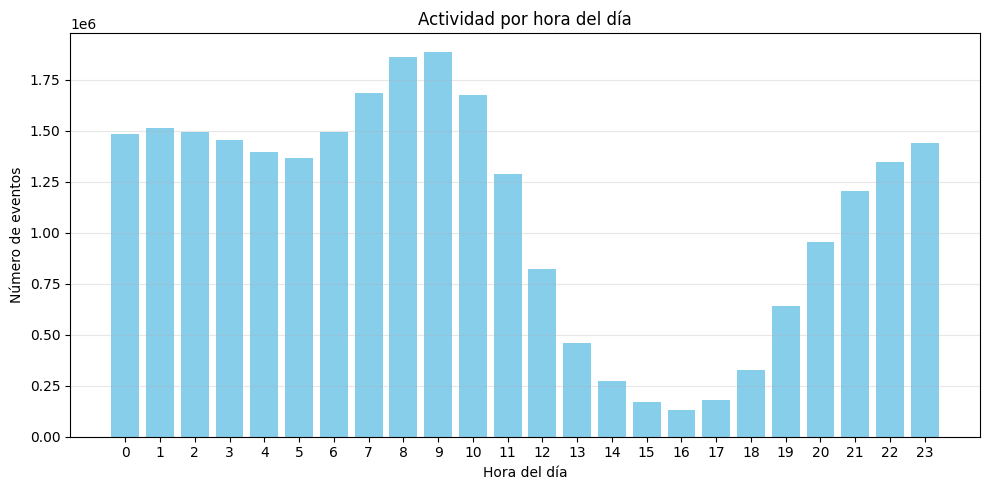

In [11]:
# === Actividad por hora del día ===
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, hour, to_timestamp

print("=== Actividad por hora del día ===")

timestamp_cols = [
    c for c in df.columns
    if c.lower() in ("event_time", "timestamp", "created_at", "datetime", "event_timestamp", "time", "date")
]

if not timestamp_cols:
    print("No se encontró una columna de marca de tiempo conocida. Revisar nombres como event_time, timestamp o created_at.")
else:
    ts_col = timestamp_cols[0]
    print(f"Usando columna de tiempo: {ts_col}")

    df_hour = df.withColumn("event_ts", to_timestamp(col(ts_col)))
    df_hour = df_hour.withColumn("hour_of_day", hour(col("event_ts")))
    df_hour = df_hour.filter(col("event_ts").isNotNull())

    agg_hour = df_hour.groupBy("hour_of_day").count().orderBy("hour_of_day")
    pdf_hour = agg_hour.toPandas()

    if pdf_hour.empty:
        print("No hay datos válidos de fecha/hora para graficar.")
    else:
        print(pdf_hour)
        plt.figure(figsize=(10, 5))
        plt.bar(pdf_hour["hour_of_day"], pdf_hour["count"], color="skyblue")
        plt.title("Actividad por hora del día")
        plt.xlabel("Hora del día")
        plt.ylabel("Número de eventos")
        plt.xticks(range(0, 24))
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

=== Ventas por brand (barra horizontal) ===
Usando columna de ventas: price


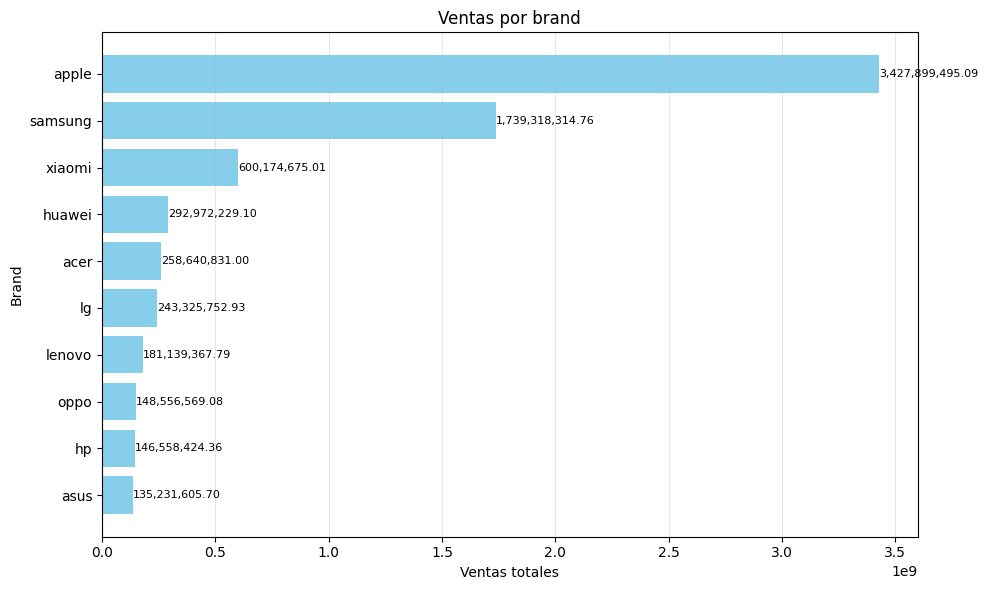

In [12]:
# === Ventas por brand (barra horizontal) ===
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, expr, sum as spark_sum

print("=== Ventas por brand (barra horizontal) ===")

sales_cols = [c for c in ["sales", "amount", "price", "total", "revenue"] if c in df.columns]
if "brand" not in df.columns:
    print("No se encontró la columna 'brand' en el DataFrame.")
elif not sales_cols:
    print("No se detectó una columna de ventas. Verifica si existe 'sales', 'amount', 'price', 'total' o 'revenue'.")
else:
    sales_col = sales_cols[0]
    print(f"Usando columna de ventas: {sales_col}")

    if dict(df.dtypes)[sales_col] == "string":
        df_sales = df.withColumn("sales_num", expr(f"try_cast({sales_col} as double)"))
    else:
        df_sales = df.withColumn("sales_num", col(sales_col).cast("double"))

    df_sales = df_sales.filter(col("brand").isNotNull() & col("sales_num").isNotNull())
    agg_brand = df_sales.groupBy("brand").agg(spark_sum("sales_num").alias("sales_total")).orderBy(col("sales_total").desc()).limit(10)
    pdf_brand = agg_brand.toPandas()

    if pdf_brand.empty:
        print("No hay datos numéricos de ventas válidos para graficar.")
    else:
        pdf_brand = pdf_brand.sort_values("sales_total")
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(pdf_brand["brand"], pdf_brand["sales_total"], color="skyblue")
        ax.set_title("Ventas por brand")
        ax.set_xlabel("Ventas totales")
        ax.set_ylabel("Brand")
        ax.grid(axis="x", alpha=0.3)
        for i, v in enumerate(pdf_brand["sales_total"]):
            ax.text(v, i, f"{v:,.2f}", va="center", fontsize=8)
        plt.tight_layout()
        plt.show()

In [3]:
spark